## **DAY 8 — Time Series Analysis & Forecasting**

<br>
<br>

### **PART 1 — Understanding Time Series Data**

---

**Time Series Data** is a sequence of data points recorded at specific, equally spaced intervals over time. Unlike standard datasets where observations are independent, the order of data points in a time series is critical.

#### **Key Examples:**
*   **Finance:** Stock prices, Forex rates, Cryptocurrency values.
*   **Business:** Daily sales volume, inventory levels.
*   **Science:** Hourly weather temperatures, seismic activity.

| Date | Price |
| :--- | :--- |
| Jan 1 | 100 |
| Jan 2 | 102 |
| Jan 3 | 101 |

---

<br>
<br>


### **PART 2 — Components of Time Series**

---

To analyze time series effectively, we decompose the data into three primary components:

#### **1. Trend 📈**
The long-term increase or decrease in the data. It represents the "big picture" direction over a long period.
*   **Upward Trend:** Growing population, increasing stock market index.
*   **Downward Trend:** Decreasing cost of technology over time.
*   **Horizontal/Stationary:** Data fluctuates around a constant mean.

> **Visual Concept:** `100 → 110 → 120 → 130` (A clear upward trajectory).

#### **2. Seasonality 🔁**
Patterns that repeat at fixed intervals (e.g., daily, weekly, monthly, or quarterly). These are usually linked to the calendar or clock.
*   **Examples:** Retail sales spiking every December, electricity usage peaking during summer (AC) or winter (Heating).
*   **Pattern:** High → Low → High → Low (Predictable cycles).

#### **3. Noise (Irregularity/Residual) 🎲**
Random fluctuations that cannot be explained by trend or seasonality. These are unpredictable and often caused by unique, one-off events.
*   **Examples:** A sudden market crash, a natural disaster affecting supply chains, or simple measurement errors.
*   **Characteristics:** Non-systematic and short-term.

<br>
<br>


### **PART 3 — Time Series Visualization**

---

To understand a time series, the first step is always visualization. This allows us to spot trends, seasonality, and outliers immediately.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Create a sample Time Series dataset
data = {
    "Date": pd.date_range(
        start="2025-01-01",
        periods=10
    ),
    "Price": [
        100, 102, 101, 105, 110,
        108, 115, 117, 120, 125
    ]
}

df = pd.DataFrame(data)
display(df)

,Date,Price
0,2025-01-01,100
1,2025-01-02,102
2,2025-01-03,101
3,2025-01-04,105
4,2025-01-05,110
5,2025-01-06,108
6,2025-01-07,115
7,2025-01-08,117
8,2025-01-09,120
9,2025-01-10,125


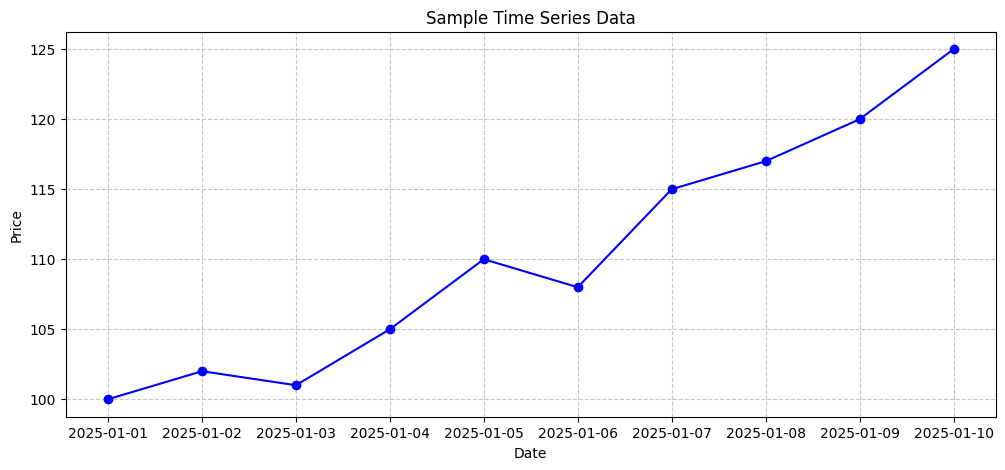

In [4]:
# Plot the Time Series
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Price"], marker='o', linestyle='-', color='b')

# Add labels and title
plt.title("Sample Time Series Data")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

<br>
<br>



### **PART 4 — Stationarity**

---

**Stationarity** is a property of a time series where the statistical characteristics (like mean, variance, and autocorrelation) are constant over time.

#### **What is Stationary Data?**
A stationary time series is 'flat' and predictable in its behavior:
*   **Stable Mean:** The average value doesn't drift up or down.
*   **Stable Variance:** The spread of data (volatility) remains consistent.
*   **Stable Covariance:** The relationship between different periods is constant.

#### **Why is it Important?**
Most forecasting models (like ARIMA or Linear Regression) assume the data is stationary. If the mean changes over time (like a stock market growing forever), the model will struggle to make accurate future predictions.

#### **Examples**
*   **Non-Stationary:** `100 → 150 → 300 → 500` (The mean is clearly increasing).
*   **Stationary:** White noise or data that has been 'differenced' to remove trends.

<br>
<br>


### **PART 5 — Lag Features**

---

**Lag features** are the primary way we turn a time series problem into a supervised learning problem. We use values from previous time steps as inputs to predict the current or future values.

*   **Lag 1:** The value at time `t-1` (yesterday's price).
*   **Lag 2:** The value at time `t-2` (price from two days ago).

#### **Why Important?**
Lag features allow the model to capture **momentum** and **autocorrelation**. If the price was high yesterday, it often provides a strong hint about the price today.

In [5]:
# Create Lag Features using .shift()
df["lag_1"] = df["Price"].shift(1)
df["lag_2"] = df["Price"].shift(2)

# Display the dataframe with lags
# Note: The first few rows will have NaN (Not a Number) because there is no prior data to 'shift' from.
display(df)

,Date,Price,lag_1,lag_2
0,2025-01-01,100,NaN,NaN
1,2025-01-02,102,100.0,NaN
2,2025-01-03,101,102.0,100.0
3,2025-01-04,105,101.0,102.0
4,2025-01-05,110,105.0,101.0
5,2025-01-06,108,110.0,105.0
6,2025-01-07,115,108.0,110.0
7,2025-01-08,117,115.0,108.0
8,2025-01-09,120,117.0,115.0
9,2025-01-10,125,120.0,117.0


<br>
<br>


### **PART 6 — Rolling Features**

---

Rolling features (also known as moving windows) are used to capture local statistics over a specific period.

*   **Rolling Mean:** Smooths out short-term fluctuations to highlight longer-term trends.
*   **Rolling Standard Deviation:** Measures the dispersion of data, which in finance is often used as a proxy for **volatility** or risk.

In [6]:
# Calculate Rolling Mean and Std with a window of 3 days
df["rolling_mean"] = df["Price"].rolling(window=3).mean()
df["rolling_std"] = df["Price"].rolling(window=3).std()

display(df[["Date", "Price", "rolling_mean", "rolling_std"]])

,Date,Price,rolling_mean,rolling_std
0,2025-01-01,100,NaN,NaN
1,2025-01-02,102,NaN,NaN
2,2025-01-03,101,101.000000,1.000000
3,2025-01-04,105,102.666667,2.081666
4,2025-01-05,110,105.333333,4.509250
5,2025-01-06,108,107.666667,2.516611
6,2025-01-07,115,111.000000,3.605551
7,2025-01-08,117,113.333333,4.725816
8,2025-01-09,120,117.333333,2.516611
9,2025-01-10,125,120.666667,4.041452


<br>
<br>


### **PART 7 — Momentum Features**

---

Momentum measures the speed or velocity of price changes. It helps identify if a trend is accelerating or slowing down.

**Formula:** `Momentum = Current Price - Previous Price (Lag 1)`

In [7]:
# Calculate Momentum
df["momentum"] = df["Price"] - df["lag_1"]

# Display the final feature set
display(df)

,Date,Price,lag_1,lag_2,rolling_mean,rolling_std,momentum
0,2025-01-01,100,NaN,NaN,NaN,NaN,NaN
1,2025-01-02,102,100.0,NaN,NaN,NaN,2.0
2,2025-01-03,101,102.0,100.0,101.000000,1.000000,-1.0
3,2025-01-04,105,101.0,102.0,102.666667,2.081666,4.0
4,2025-01-05,110,105.0,101.0,105.333333,4.509250,5.0
5,2025-01-06,108,110.0,105.0,107.666667,2.516611,-2.0
6,2025-01-07,115,108.0,110.0,111.000000,3.605551,7.0
7,2025-01-08,117,115.0,108.0,113.333333,4.725816,2.0
8,2025-01-09,120,117.0,115.0,117.333333,2.516611,3.0
9,2025-01-10,125,120.0,117.0,120.666667,4.041452,5.0


<br>
<br>


### **PART 8 — Exponential Weighted Mean (EWM)**

---

While simple rolling means treat all values in the window equally, **EWM** gives more weight to the most recent observations. This makes it more responsive to sudden shifts in data.

*   **Usage:** Widely used in technical indicators like MACD or RSI to identify current market trends.

In [8]:
# Calculate Exponential Weighted Moving Average
df["ewm"] = df["Price"].ewm(span=3).mean()

display(df[["Date", "Price", "rolling_mean", "ewm"]])

,Date,Price,rolling_mean,ewm
0,2025-01-01,100,NaN,100.000000
1,2025-01-02,102,NaN,101.333333
2,2025-01-03,101,101.000000,101.142857
3,2025-01-04,105,102.666667,103.200000
4,2025-01-05,110,105.333333,106.709677
5,2025-01-06,108,107.666667,107.365079
6,2025-01-07,115,111.000000,111.212598
7,2025-01-08,117,113.333333,114.117647
8,2025-01-09,120,117.333333,117.064579
9,2025-01-10,125,120.666667,121.036168


<br>
<br>


### **PART 9 — Time-Based Train-Test Split**

---

**CRITICAL RULE:** In standard ML, we shuffle data. In Time Series, we **never** shuffle. Shuffling causes 'data leakage' where the model accidentally sees the future to predict the past.

We must split the data at a specific point in time so that the training set occurs strictly before the test set.

In [9]:
# 80% for training, 20% for testing
train_size = int(len(df) * 0.8)

train = df[:train_size]
test = df[train_size:]

print(f"Training set rows: {len(train)}")
print(f"Testing set rows: {len(test)}")

# Display the split point
print(f"\nLast training date: {train['Date'].max()}")
print(f"First testing date: {test['Date'].min()}")

Training set rows: 8
Testing set rows: 2

Last training date: 2025-01-08 00:00:00
First testing date: 2025-01-09 00:00:00


<br>
<br>


### **PART 10 — Forecasting with Random Forest**

---

Tree-based models like **Random Forest** are powerful for time series because they don't assume a linear relationship between features and the target.

We will prepare our features, drop the resulting `NaN` values, and train the model.

In [10]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1. Prepare the final dataset (Handling NaNs from lags/rolling)
df_ml = df.dropna().copy()

# 2. Define Features & Target
features = ["lag_1", "lag_2", "rolling_mean", "momentum", "ewm"]
X = df_ml[features]
y = df_ml["Price"]

# 3. Time-Based Split for ML
split_idx = int(len(df_ml) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# 4. Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict
rf_predictions = rf_model.predict(X_test)

print(f"Test Set Predictions: {rf_predictions}")
print(f"Actual Prices: {y_test.values}")

Test Set Predictions: [115.56 115.41]
Actual Prices: [120 125]


<br>
<br>


### **PART 11 — Forecasting Metrics**

---

To know if our model is any good, we use specific error metrics:

*   **MAE (Mean Absolute Error):** The average of the absolute differences between predictions and actual values.
*   **RMSE (Root Mean Squared Error):** This penalizes larger errors more heavily.

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, rf_predictions)
rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 7.02
Root Mean Squared Error (RMSE): 7.47


<br>
<br>

### **PART 12 — Real Industry Understanding**

Forecasting isn't just a mathematical exercise; it's the backbone of modern business operations.

| Industry | Usage |
| :--- | :--- |
| **Finance** | Predicting stock movements and risk management. |
| **Retail** | Sales forecasting to optimize inventory and supply chains. |
| **Energy** | Demand forecasting to prevent grid overloads. |
| **Banking** | Credit risk prediction based on spending patterns over time. |
| **Crypto** | Price forecasting and volatility (risk) estimation. |

<br>
<br>


### **PART 13 — FULL FORECASTING EXAMPLE**

---

This section consolidates our workflow into a single, repeatable process: defining data, engineering features, training a model, and generating predictions.

In [13]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# Step 1 — Dataset
data = {
    "Price": [
        100, 102, 101, 105,
        110, 108, 115, 117
    ]
}
df_example = pd.DataFrame(data)

# Step 2 — Feature Engineering
df_example["lag_1"] = df_example["Price"].shift(1)
df_example["rolling_mean"] = df_example["Price"].rolling(3).mean()
df_example["momentum"] = df_example["Price"] - df_example["lag_1"]

df_example.dropna(inplace=True)

# Step 3 — Train Model
X_ex = df_example[["lag_1", "rolling_mean", "momentum"]]
y_ex = df_example["Price"]

model_ex = RandomForestRegressor(n_estimators=100, random_state=42)
model_ex.fit(X_ex, y_ex)

# Step 4 — Predict
predictions_ex = model_ex.predict(X_ex)

print("Forecasted values for the training period:")
print(predictions_ex)

Forecasted values for the training period:
[102.7  104.81 108.54 109.58 114.15 115.16]


<br>
<br>

## **PRATICE DATASET**

In [14]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)

# 1. Generate Business Timestamps (30 consecutive days)
dates = pd.date_range(start="2026-01-01", periods=30, freq="D")

# 2. Replicate and Scale Your Base Trend
# Your original data grew from ~100 to ~128 over 12 days (approx +2.3 per day)
base_trend = 100 + (np.arange(30) * 2.3)

# 3. Add Weekly Seasonality (Interview Curveball: Price dips 4% on weekends)
day_of_week = dates.dayofweek
seasonality = np.where(day_of_week >= 5, -4.0, 1.5)

# 4. Add Random Market Noise
noise = np.random.normal(loc=0, scale=1.5, size=30)

# 5. Combine into the Final Upgraded Price
final_prices = np.round(base_trend + seasonality + noise, 2)

# Create the Interview-Ready DataFrame
df_practice = pd.DataFrame({"Date": dates, "Price": final_prices})

# Inspect the dataset
print(f"Dataset Shape: {df_practice.shape}")
display(df_practice.head(10))

Dataset Shape: (30, 2)


,Date,Price
0,2026-01-01,102.25
1,2026-01-02,103.59
2,2026-01-03,101.57
3,2026-01-04,105.18
4,2026-01-05,110.35
5,2026-01-06,112.65
6,2026-01-07,117.67
7,2026-01-08,118.75
8,2026-01-09,119.20
9,2026-01-10,117.51


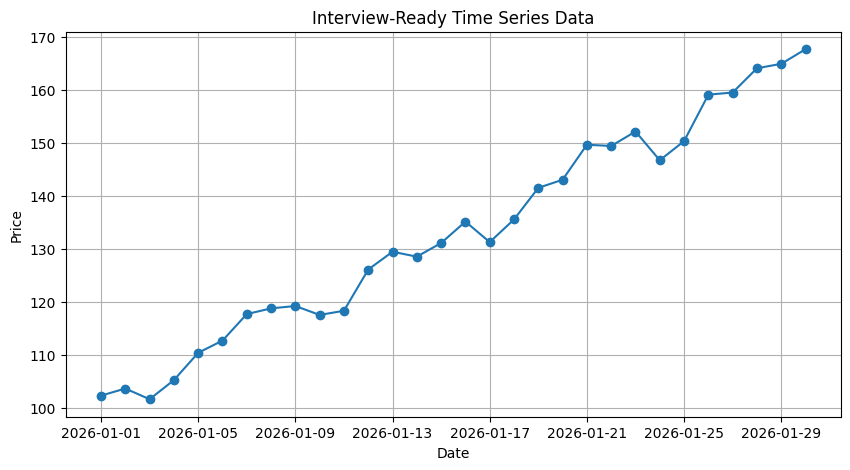

In [15]:
#STEP  1: VISUALIZATION
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_practice['Date'], df_practice['Price'], marker='o', linestyle='-')
plt.title('Interview-Ready Time Series Data')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True)
plt.show()


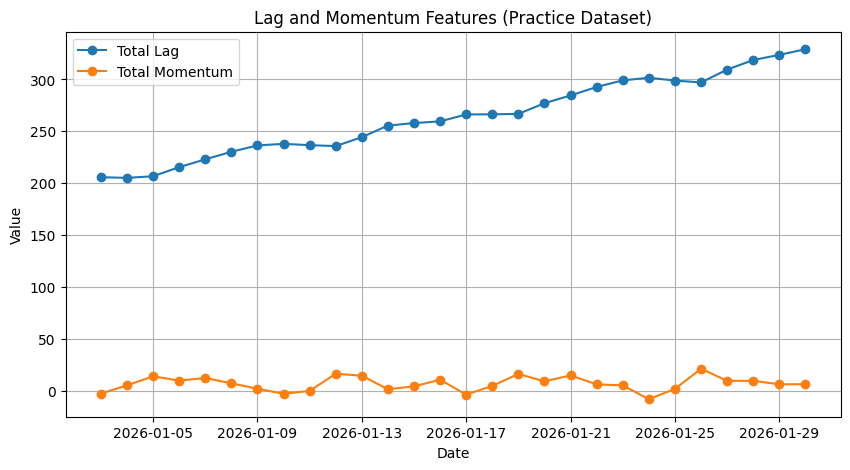

In [34]:
#STEP 2: FEATURE ENGINEERING

# Apply features to the practice dataset specifically
df_practice['fe_1'] = df_practice['Price'].shift(1)
df_practice['fe_2'] = df_practice['Price'].shift(2)

df_practice['Total_lag'] = df_practice['fe_1'] + df_practice['fe_2']

df_practice['momentum_x'] = df_practice['Price'] - df_practice['fe_1']
df_practice['momentum_y'] = df_practice['Price'] - df_practice['fe_2']

df_practice['Total_momentum'] = df_practice['momentum_x'] + df_practice['momentum_y']

df_practice['rolling_3'] = df['Price'].rolling(window=3).mean()
df_practice['rolling_4'] = df['Price'].rolling(window=3).std()



plt.figure(figsize=(10, 5))
plt.plot(df_practice['Date'], df_practice['Total_lag'], marker='o', linestyle='-', label='Total Lag')
plt.plot(df_practice['Date'], df_practice['Total_momentum'], marker='o', linestyle='-', label='Total Momentum')
plt.title('Lag and Momentum Features (Practice Dataset)')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

In [21]:
# 1. Prepare Features & Target (Drop NaNs from lags)
df_practice_ml = df_practice.dropna().copy()

features = ['fe_1', 'fe_2', 'Total_lag', 'momentum_x', 'momentum_y', 'Total_momentum']
X = df_practice_ml[features]
y = df_practice_ml['Price']

# 2. Time-Based Split
split_idx = int(len(df_practice_ml) * 0.8)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 22
Testing samples: 6


Interview Challenge Results:
- MAE: 11.70
- RMSE: 13.05


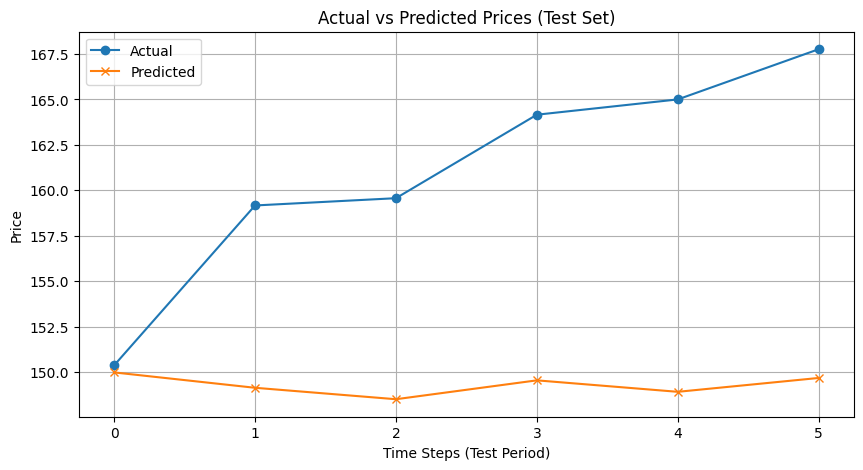

In [23]:
# STEP 3: MODEL TRAINING AND EVALUATION
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# 1. Train the Random Forest
rf_practice = RandomForestRegressor(n_estimators=100, random_state=42)
rf_practice.fit(X_train, y_train)

# 2. Predict on the test set
preds = rf_practice.predict(X_test)

# 3. Calculate Metrics
mae_p = mean_absolute_error(y_test, preds)
rmse_p = np.sqrt(mean_squared_error(y_test, preds))

print(f"Interview Challenge Results:")
print(f"- MAE: {mae_p:.2f}")
print(f"- RMSE: {rmse_p:.2f}")

# 4. Visualize Results
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(preds, label='Predicted', marker='x')
plt.title('Actual vs Predicted Prices (Test Set)')
plt.xlabel('Time Steps (Test Period)')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

## **PRATICE DATASET 2**

**Scenario:** Predict daily product demand. Unlike stock prices, retail demand is often heavily influenced by specific promotions and inventory availability.

**New Concept: Exogenous Variables**
In this challenge, you will use 'Is_Promo' as an additional feature alongside your time-based features.

**Tasks:**
1.  Generate a 60-day dataset with a weekly cycle.
2.  Add a **'Promotion'** flag that increases demand.
3.  Feature Engineer: Add Lags and a **3-day Rolling Mean**.
4.  Train a model and evaluate results.

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup Dataset (60 Days)
np.random.seed(7)
dates = pd.date_range(start="2026-05-01", periods=60, freq="D")

# Base demand + weekly seasonality
day_of_week = dates.dayofweek
base_demand = 20 + (day_of_week * 5)  # Higher demand toward the end of the week

# 2. Add Promotions (Exogenous variable)
promo_flag = np.random.choice([0, 1], size=60, p=[0.8, 0.2])
demand = base_demand * (1 + promo_flag * 0.5) + np.random.normal(0, 3, 60)

df_retail = pd.DataFrame({
    "Date": dates,
    "Demand": np.round(demand).astype(int),
    "Is_Promo": promo_flag
})

print("Retail Dataset Created:")
display(df_retail.head(10))

Retail Dataset Created:


,Date,Demand,Is_Promo
0,2026-05-01,40,0
1,2026-05-02,46,0
2,2026-05-03,50,0
3,2026-05-04,19,0
4,2026-05-05,33,1
5,2026-05-06,32,0
6,2026-05-07,35,0
7,2026-05-08,44,0
8,2026-05-09,44,0
9,2026-05-10,44,0


**Your Turn:**
- Calculate a 1-day lag of `Demand`.
- Calculate a 3-day rolling mean of `Demand`.
- Split the data (80/20).
- Train a model to predict `Demand` using `Is_Promo`, `lag_1`, and `rolling_3`.

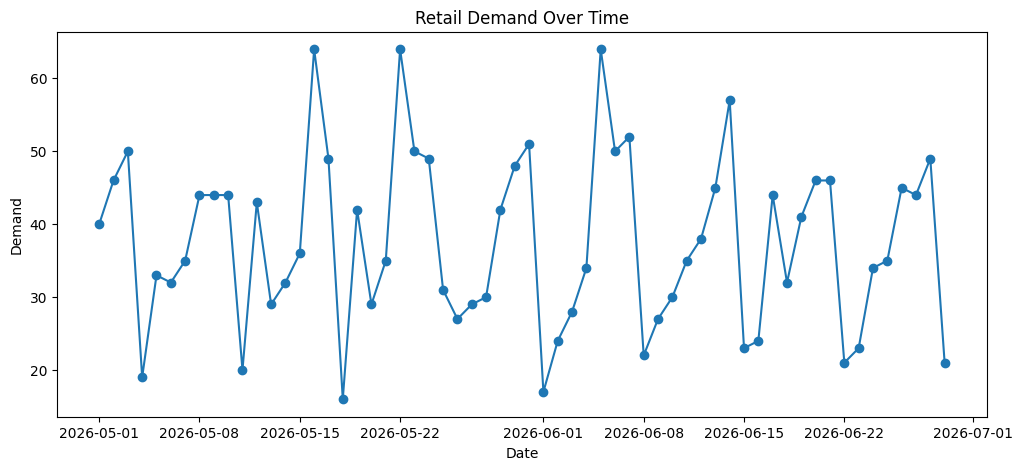

In [30]:
#STEP 1: VISUALIZATION

plt.figure(figsize=(12, 5))
plt.plot(df_retail['Date'], df_retail['Demand'], marker='o', linestyle='-')
plt.title('Retail Demand Over Time')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.show()

In [33]:
#STEP 2 FEATURE ENGINEERING
# Lags
df_retail['br_1'] = df_retail['Demand'].shift(1)
df_retail['br_2'] = df_retail['Demand'].shift(2)

# Momentum
df_retail['moment_1'] = df_retail['Demand'] - df_retail['br_1']
df_retail['moment_2'] = df_retail['Demand'] - df_retail['br_2']

# Rolling Mean (As requested in tasks)
df_retail['rolling_3'] = df_retail['Demand'].rolling(window=3).mean()

# Inspect the new features
display(df_retail.head())

,Date,Demand,Is_Promo,br_1,br_2,moment_1,moment_2,rolling_3
0,2026-05-01,40,0,NaN,NaN,NaN,NaN,NaN
1,2026-05-02,46,0,40.0,NaN,6.0,NaN,NaN
2,2026-05-03,50,0,46.0,40.0,4.0,10.0,45.333333
3,2026-05-04,19,0,50.0,46.0,-31.0,-27.0,38.333333
4,2026-05-05,33,1,19.0,50.0,14.0,-17.0,34.000000


In [35]:
#STEP 3: SPLITTING THE DATA

X = df_retail[['Is_Promo',	'br_1',	'br_2',	'moment_1',	'moment_2',	'rolling_3']]
y = df_retail['Demand']
split_x =  int(len(df_retail) * 0.8)

X_train, X_test = X[:split_x], X[split_x:]
y_train, y_test = y[:split_x], y[split_x:]

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 48
Testing samples: 12


In [37]:
#STEP 4: MODEL IMPLEMENTATION
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Handle NaNs (Critical for Time Series features)
# We drop rows where lags or rolling means are NaN
X_train_clean = X_train.dropna()
y_train_clean = y_train[X_train_clean.index]

# 2. Train Model
rt_model = RandomForestRegressor(n_estimators=100, random_state=42)
rt_model.fit(X_train_clean, y_train_clean)

# 3. Predict
# Note: X_test should not have NaNs if the split happened after the first few rows
yx_pred = rt_model.predict(X_test)

# 4. CALCULATE METRICS
ac_mae = mean_absolute_error(y_test, yx_pred)
ac_rmse = np.sqrt(mean_squared_error(y_test, yx_pred))

print(f"Random Forest Results:")
print(f"- MAE: {ac_mae:.2f}")
print(f"- RMSE: {ac_rmse:.2f}")

Random Forest Results:
- MAE: 1.54
- RMSE: 1.75
